# 步驟二：探索性資料分析 (Exploratory Data Analysis, EDA)

本階段的分析目標：
1. **整體數據輪廓**：檢視清理後的資料分佈與敘述統計。
2. **變數相關性**：透過熱力圖找出與氣候災害影響力（如嚴重程度、受災人口、經濟損失）高度相關的特徵，為後續的迴歸分析鋪路。
3. **災損分佈比較**：利用箱型圖與散佈圖，視覺化不同變數之間的交互關係，並尋找潛在的極端值（長尾分佈）。

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 設定繪圖風格
sns.set_theme(style="whitegrid")


print("繪圖套件與環境設定完成！")

繪圖套件與環境設定完成！


In [46]:
import os


# 檢查目前是不是在 notebooks 資料夾裡，如果是，就退回/workspace
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

# 動態獲取專案根目錄並讀取 standardized 資料夾中的乾淨資料

BASE_DIR = Path.cwd() 
file_path = BASE_DIR  / 'data' / 'standardized' / 'global_climate_events_economic_impact_2020_2025_standardized.csv'

df = pd.read_csv(file_path)

print(f"資料讀取成功！共 {df.shape[0]} 筆紀錄，{df.shape[1]} 個特徵。")

資料讀取成功！共 3000 筆紀錄，20 個特徵。


### 1. 敘述統計摘要 (Descriptive Statistics)
觀察資料的平均值、標準差與四分位數。因為在步驟一已經做過 Z-score 標準化，這裡數值型特徵的平均值應該都要趨近於 0，標準差趨近於 1。

In [47]:
# 顯示數值欄位的統計摘要
display(df.describe().round(4))

,year,month,severity,duration_days,affected_population,deaths,injuries,economic_impact_million_usd,infrastructure_damage_score,response_time_hours,international_aid_million_usd,latitude,longitude,total_casualties,impact_per_capita,aid_percentage
count,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000
mean,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000
std,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002
min,-1.4524,-1.5625,-1.3898,-0.5970,-0.2884,-0.4188,-0.4978,-0.1236,-1.3009,-1.3457,-0.0190,-1.7258,-1.7306,-0.5102,-0.3353,-0.0217
25%,-0.8477,-0.9684,-0.8910,-0.5290,-0.2705,-0.3281,-0.3709,-0.1230,-0.7966,-0.7399,-0.0190,-0.8629,-0.8633,-0.3822,-0.3279,-0.0217
50%,-0.2429,-0.0773,0.1066,-0.4611,-0.2293,-0.2373,-0.2694,-0.1179,-0.2401,-0.2553,-0.0190,-0.0280,-0.0023,-0.2775,-0.2908,-0.0217
75%,0.9666,0.8138,0.6054,0.0147,-0.0865,-0.1466,-0.1552,-0.0899,0.5447,0.4715,-0.0190,0.9009,0.9024,-0.1727,-0.1374,-0.0217
max,1.5713,1.7049,2.6006,7.2197,18.4036,10.1986,8.8170,45.5282,4.1600,5.9232,54.7198,1.7321,1.7330,8.0782,16.5156,53.5508


### 2. 變數相關性分析 (Correlation Analysis)
純看數值不直觀，透過 Pearson 相關係數熱力圖，我們可以快速掃描哪些變數之間存在強烈的正相關或負相關，顏色越紅的相關係數越高。

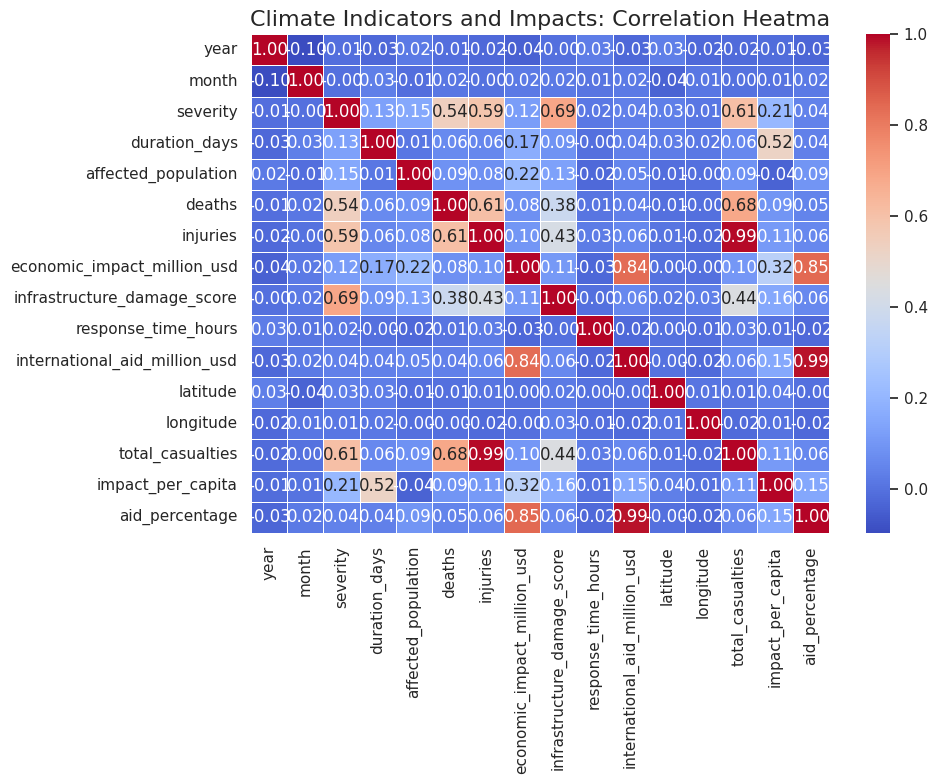

In [48]:
plt.figure(figsize=(10, 8))

# 自動篩選出數值型欄位來計算相關係數
num_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = num_df.corr()

# 繪製熱力圖
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Climate Indicators and Impacts: Correlation Heatma', fontsize=16)
plt.tight_layout()
plt.show()

### 3. 特定變數檢視
利用箱型圖，檢視特定變數的分布

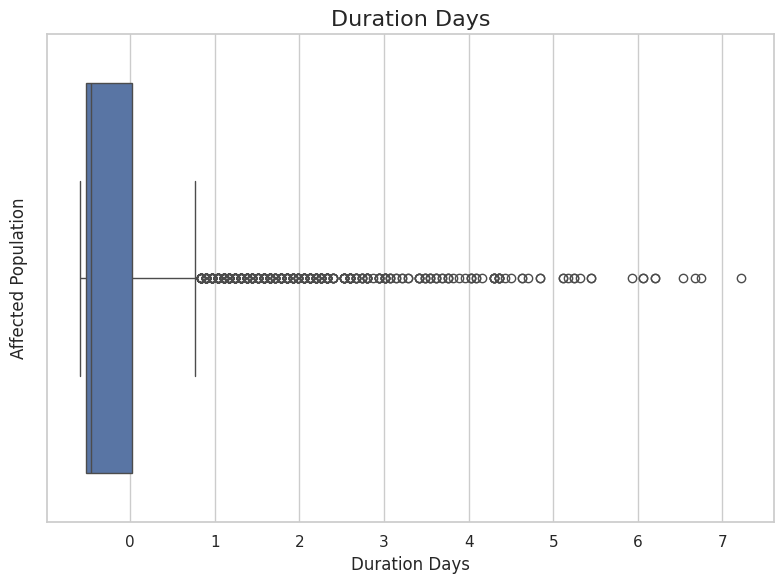

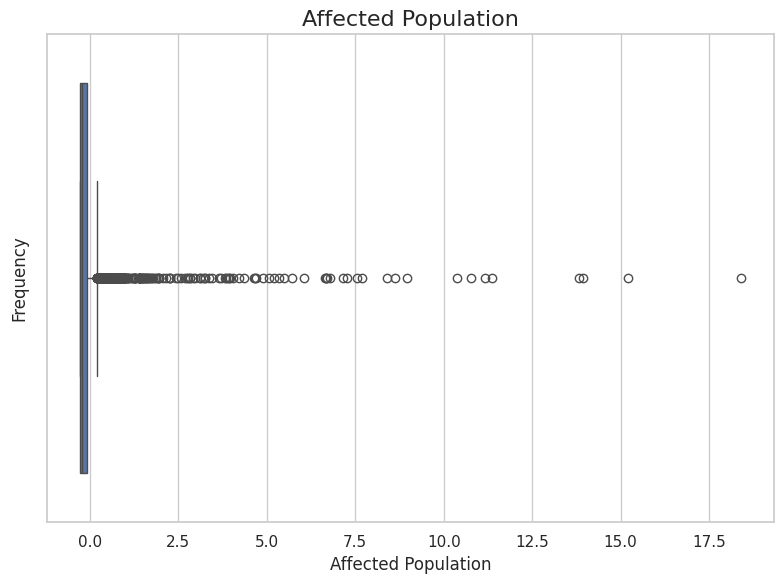

In [49]:
# 探討「持續天數 (duration_days)」的箱型圖
plt.figure(figsize=(8, 6))
sns.boxplot(x='duration_days', data=df)
plt.title('Duration Days', fontsize=16)
plt.xlabel('Duration Days', fontsize=12)
plt.ylabel('Affected Population', fontsize=12)
plt.tight_layout()
plt.show()
# 受災人口(affected_population)的箱型圖
plt.figure(figsize=(8, 6))
sns.boxplot(x='affected_population', data=df)
plt.title('Affected Population', fontsize=16)
plt.xlabel('Affected Population', fontsize=12)  
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

### 4. 災害影響分佈與趨勢 (Distribution & Trends)
利用散佈圖與迴歸趨勢線，進一步探討兩個特定連續變數之間的關係。

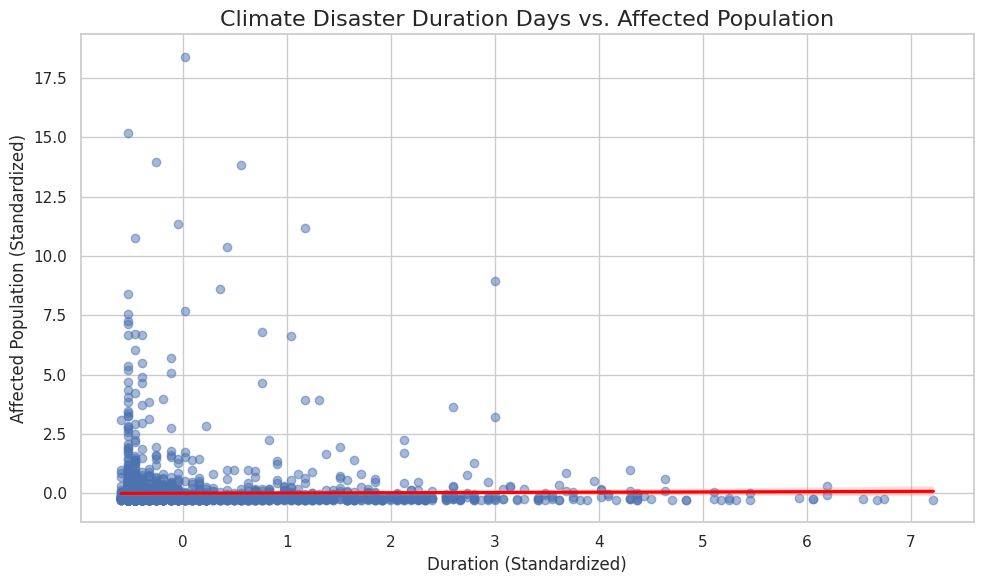

In [50]:
# 探討「持續天數 (duration_days)」與「受災人口 (affected_population)」的關係
# 註：若有 economic_loss 欄位，可將 y 替換為 economic_loss
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df, 
    x='duration_days', 
    y='affected_population', 
    scatter_kws={'alpha':0.5}, # 點的透明度
    line_kws={'color':'red'}   # 迴歸線的顏色
)

plt.title('Climate Disaster Duration Days vs. Affected Population', fontsize=16)
plt.xlabel('Duration (Standardized)', fontsize=12)
plt.ylabel('Affected Population (Standardized)', fontsize=12)
plt.tight_layout()
plt.show()

### 5. 統計觀察與小結
我們可以看，災害持續時間和受影響人數的箱型圖很相似，都是往上有極端值的趨勢，
從直覺上來看，兩者應該是呈高度正相關，畢竟持續時間增加會增加受影響人數，
但根據熱力圖的資訊，相關係數很低，由散布圖也能看出來，兩者並沒有呈現高度正相關，
我們透過統計的方法，發現了常見的迷思。
